# Predicting Wikipedia Article Quality from Structural and Content Features
Sahana Bai Sankarrao — MATH5872M

## Section 1 : Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})


## Section 2 : Load Data
Loads the cleaned dataset

In [2]:
df = pd.read_csv('wikipedia_final.csv')

FEATURES = ['length', 'refs', 'images', 'sections', 'links', 'infobox']

print(f"Dataset shape: {df.shape}")
print(f"\nSix-class label distribution:")
print(df['quality_real'].value_counts())
print(f"\nThree-class label distribution:")
print(df['quality_3class'].value_counts())
print(f"\nTopic category distribution:")
print(df['topic'].value_counts())

Dataset shape: (1187, 11)

Six-class label distribution:
quality_real
Start    395
C        339
B        199
Stub     196
GA        44
FA        14
Name: count, dtype: int64

Three-class label distribution:
quality_3class
Low       591
Medium    538
High       58
Name: count, dtype: int64

Topic category distribution:
topic
General                 387
History & Politics      263
Science & Technology    252
Geography               179
Culture & Arts           71
Biography                35
Name: count, dtype: int64


## Section 3 : Exploratory Data Analysis

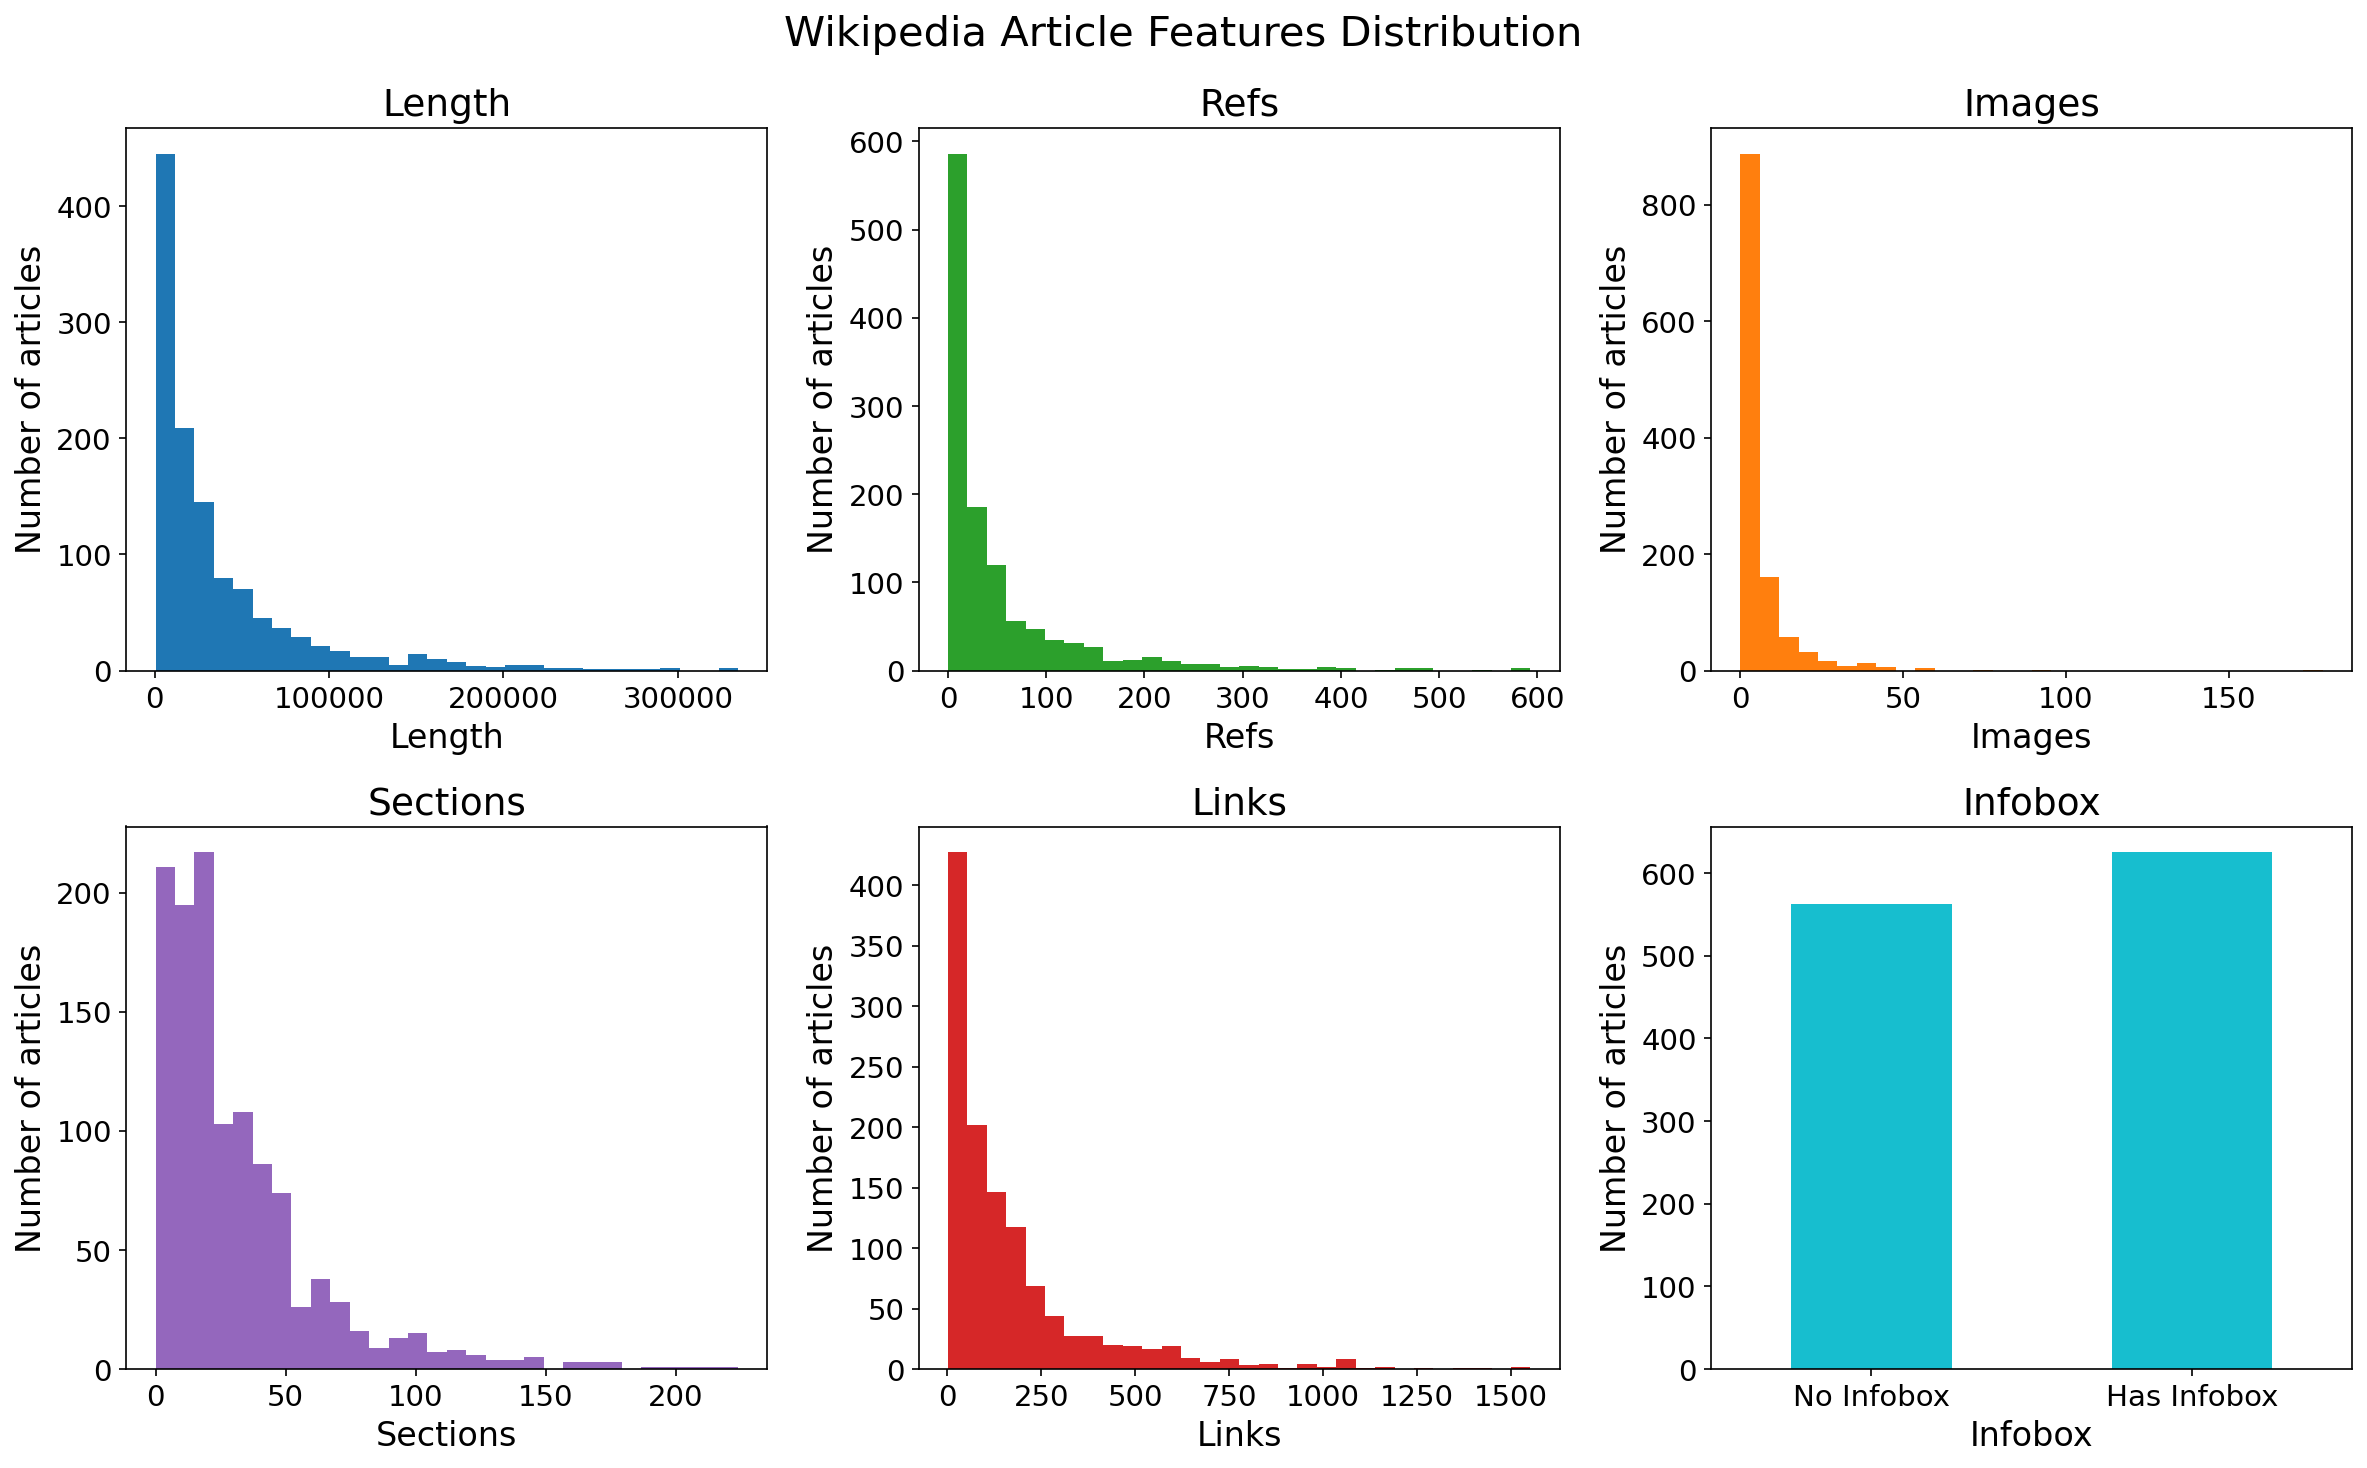

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Wikipedia Article Features Distribution', fontsize=20)
for ax, feat, color in zip(axes.flat, FEATURES, ['tab:blue','tab:green','tab:orange','tab:purple','tab:red','tab:cyan']):
    if feat == 'infobox':
        df[feat].value_counts().sort_index().plot(kind='bar', ax=ax, color=color)
        ax.set_xticklabels(['No Infobox', 'Has Infobox'], rotation=0)
        ax.set_xlabel('Infobox')
        ax.set_ylabel('Number of articles')
    else:
        ax.hist(df[feat], bins=30, color=color)
        ax.set_xlabel(feat.capitalize())
        ax.set_ylabel('Number of articles')
    ax.set_title(feat.capitalize())
plt.tight_layout()
plt.savefig('feature_distributions.png')
plt.show()


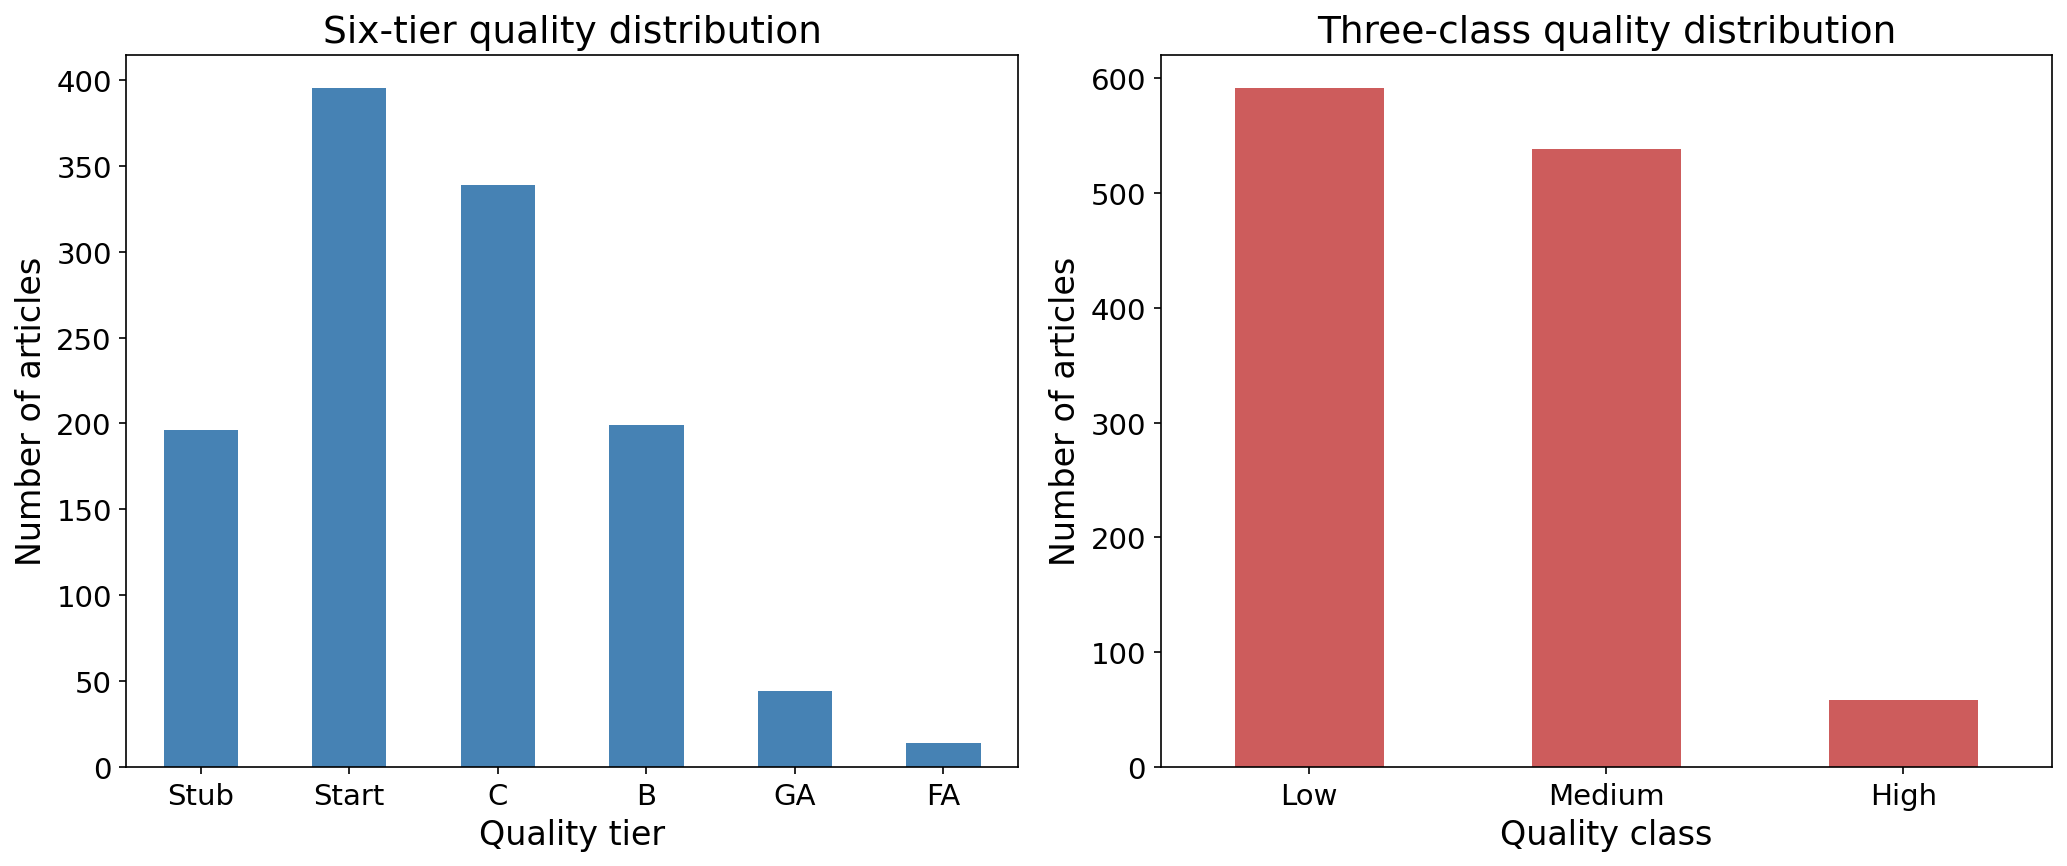

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
df['quality_real'].value_counts().reindex(['Stub','Start','C','B','GA','FA']).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Six-tier quality distribution')
axes[0].set_xlabel('Quality tier')
axes[0].set_ylabel('Number of articles')
axes[0].tick_params(axis='x', rotation=0)
df['quality_3class'].value_counts().reindex(['Low','Medium','High']).plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Three-class quality distribution')
axes[1].set_xlabel('Quality class')
axes[1].set_ylabel('Number of articles')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('quality_distributions.png')
plt.show()


### 3.5.1 Feature Collinearity Check 

In [5]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv('wikipedia_final.csv')
features = ['length', 'refs', 'images', 'sections', 'links', 'infobox']
X = df[features].astype(float)

corr = X.corr().round(2)
print(corr)

vif_data = pd.DataFrame()
vif_data['feature'] = features
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(features))]
print(vif_data.round(2))

          length  refs  images  sections  links  infobox
length      1.00  0.91    0.64      0.82   0.93     0.30
refs        0.91  1.00    0.55      0.71   0.81     0.30
images      0.64  0.55    1.00      0.56   0.71     0.19
sections    0.82  0.71    0.56      1.00   0.80     0.27
links       0.93  0.81    0.71      0.80   1.00     0.31
infobox     0.30  0.30    0.19      0.27   0.31     1.00
    feature    VIF
0    length  26.18
1      refs   8.56
2    images   2.50
3  sections   5.44
4     links  15.17
5   infobox   1.76


## Section 4 : Modelling

In [6]:
X = df[FEATURES]
y3 = df['quality_3class']

X_train, X_test, y_train, y_test = train_test_split(X, y3, test_size=0.2, random_state=RANDOM_STATE)
print("Test set class counts:", y_test.value_counts().to_dict())

Test set class counts: {'Low': 126, 'Medium': 99, 'High': 13}


### 4.1 Random Forest

In [7]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_test_acc = accuracy_score(y_test, rf_pred)

rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE),
    X, y3, cv=5
)

print(f"Random Forest test accuracy: {rf_test_acc:.4f}")
print(f"Random Forest 5-fold CV mean: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")
print("\nPer-class report:")
print(classification_report(y_test, rf_pred, digits=2))

Random Forest test accuracy: 0.7395
Random Forest 5-fold CV mean: 0.7539 (+/- 0.0418)

Per-class report:
              precision    recall  f1-score   support

        High       0.50      0.15      0.24        13
         Low       0.80      0.81      0.81       126
      Medium       0.67      0.73      0.70        99

    accuracy                           0.74       238
   macro avg       0.66      0.56      0.58       238
weighted avg       0.73      0.74      0.73       238



### 4.2 XGBoost

In [8]:
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X, y3, test_size=0.2, random_state=RANDOM_STATE, stratify=y3
)
rf_strat = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE)
rf_strat.fit(X_train_strat, y_train_strat)
strat_acc = accuracy_score(y_test_strat, rf_strat.predict(X_test_strat))
print(f"Stratified-split test accuracy (sensitivity check): {strat_acc:.4f}")
print("Stratified test set class counts:", y_test_strat.value_counts().to_dict())

Stratified-split test accuracy (sensitivity check): 0.7563
Stratified test set class counts: {'Low': 118, 'Medium': 108, 'High': 12}


In [9]:
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
inv_label_map = {v: k for k, v in label_map.items()}
y_train_enc = y_train.map(label_map)
y_test_enc = y_test.map(label_map)

sample_weights = compute_sample_weight('balanced', y_train_enc)

xgb = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='mlogloss')
xgb.fit(X_train, y_train_enc, sample_weight=sample_weights)
xgb_pred = xgb.predict(X_test)
xgb_test_acc = accuracy_score(y_test_enc, xgb_pred)

print(f"XGBoost test accuracy: {xgb_test_acc:.4f}")
print("\nPer-class report:")
print(classification_report(y_test_enc, xgb_pred, target_names=['Low','Medium','High'], digits=2))

XGBoost test accuracy: 0.7353

Per-class report:
              precision    recall  f1-score   support

         Low       0.82      0.80      0.81       126
      Medium       0.67      0.72      0.69        99
        High       0.33      0.23      0.27        13

    accuracy                           0.74       238
   macro avg       0.61      0.58      0.59       238
weighted avg       0.73      0.74      0.73       238



### 4.3 Logistic Regression (baseline)

In [10]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_test_acc = accuracy_score(y_test, lr_pred)

lr_cv_scores = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    X, y3, cv=5
)

print(f"Logistic Regression test accuracy: {lr_test_acc:.4f}")
print(f"Logistic Regression 5-fold CV mean: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

C:\Users\sahan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\sahan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Logistic Regression test accuracy: 0.6008
Logistic Regression 5-fold CV mean: 0.6259 (+/- 0.0567)


C:\Users\sahan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\sahan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refe

In [11]:
from sklearn.model_selection import StratifiedKFold
 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y3_enc = y3.map(label_map)
xgb_fold_scores = []
for train_idx, test_idx in skf.split(X, y3_enc):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y3_enc.iloc[train_idx], y3_enc.iloc[test_idx]
    w_tr = compute_sample_weight('balanced', y_tr)
    m = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='mlogloss')
    m.fit(X_tr, y_tr, sample_weight=w_tr)
    xgb_fold_scores.append(accuracy_score(y_te, m.predict(X_te)))
xgb_cv_scores = np.array(xgb_fold_scores)
print(f"XGBoost 5-fold CV mean: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

XGBoost 5-fold CV mean: 0.7363 (+/- 0.0314)


### 4.4 Three algorithm comparison (Table 5.1)

In [12]:
summary = pd.DataFrame({
    'Algorithm': ['Random Forest', 'XGBoost', 'Logistic Regression'],
    'Test Accuracy': [rf_test_acc, xgb_test_acc, lr_test_acc],
    'CV Mean': [rf_cv_scores.mean(), None, lr_cv_scores.mean()]
})
print(summary)

             Algorithm  Test Accuracy   CV Mean
0        Random Forest       0.739496  0.753941
1              XGBoost       0.735294       NaN
2  Logistic Regression       0.600840  0.625905


## Section 5 : Results

### 5.1 Effect of Class Weighting (six-class)

Without balanced weighting: 0.5756
With balanced weighting:    0.5882


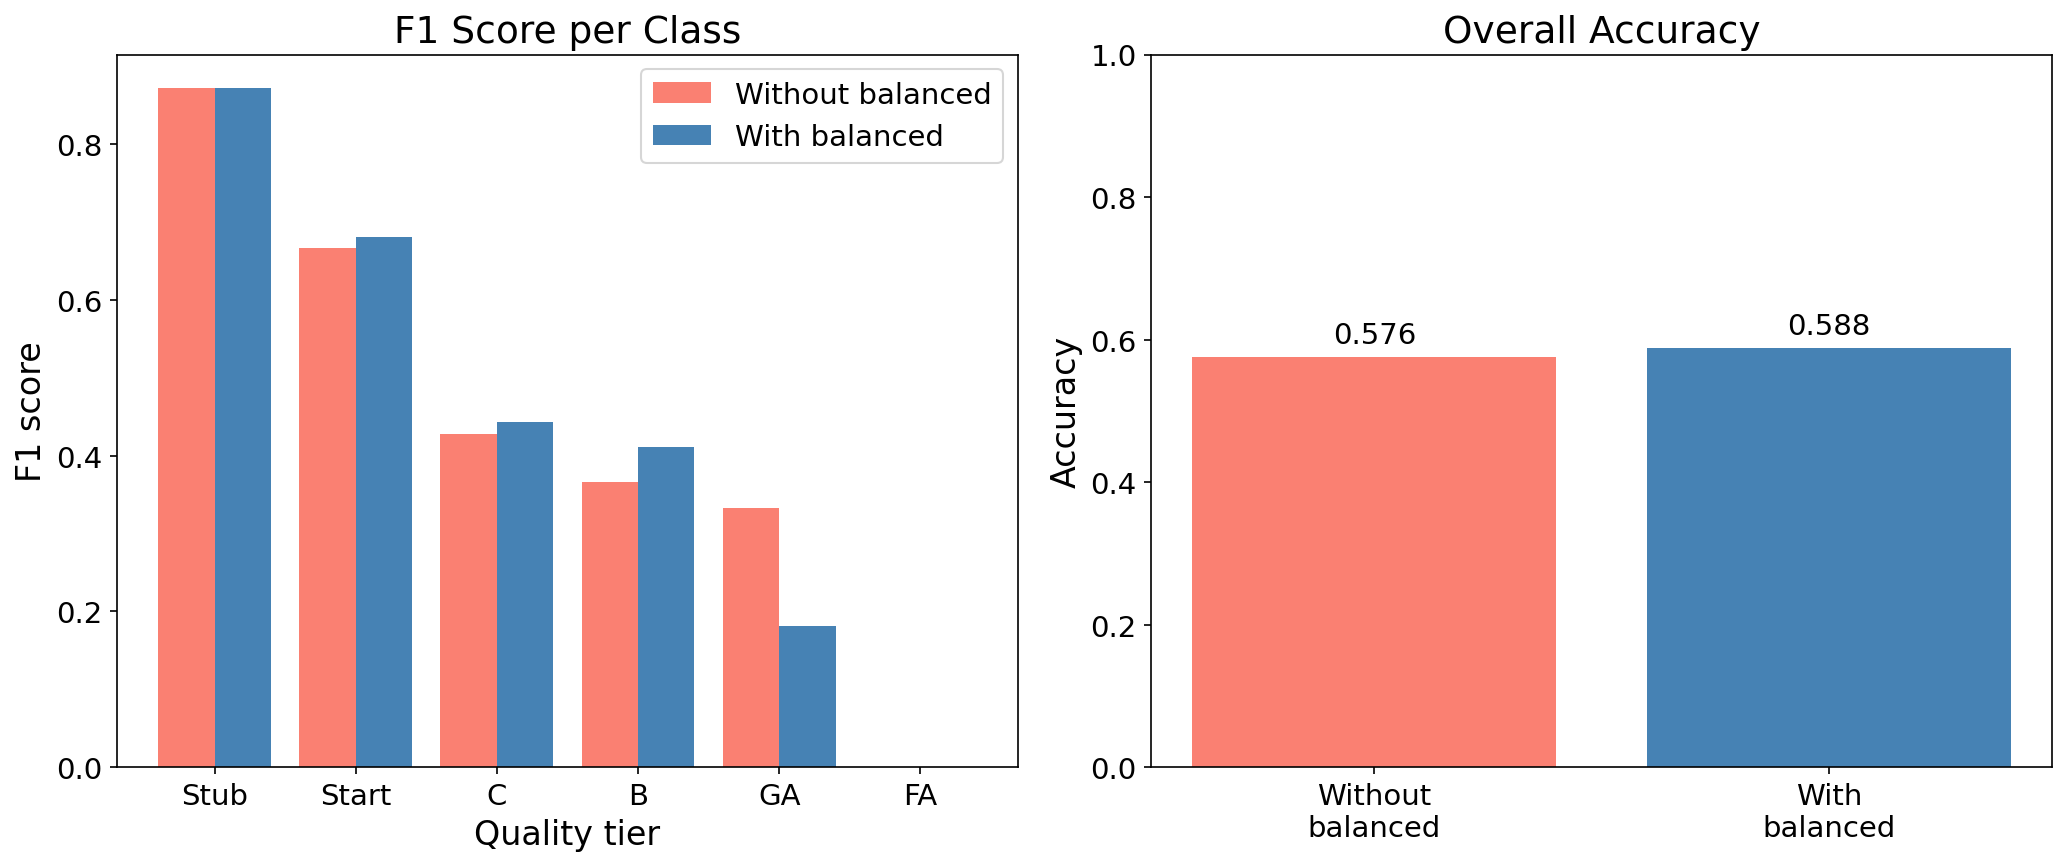

In [13]:
y6 = df['quality_real']
X_train6, X_test6, y_train6, y_test6 = train_test_split(X, y6, test_size=0.2, random_state=RANDOM_STATE)

rf_unbalanced = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_unbalanced.fit(X_train6, y_train6)
acc_unbalanced = accuracy_score(y_test6, rf_unbalanced.predict(X_test6))

rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE)
rf_balanced.fit(X_train6, y_train6)
acc_balanced = accuracy_score(y_test6, rf_balanced.predict(X_test6))

print(f"Without balanced weighting: {acc_unbalanced:.4f}")
print(f"With balanced weighting:    {acc_balanced:.4f}")

f1_unbalanced = f1_score(y_test6, rf_unbalanced.predict(X_test6), average=None, labels=['Stub','Start','C','B','GA','FA'])
f1_balanced = f1_score(y_test6, rf_balanced.predict(X_test6), average=None, labels=['Stub','Start','C','B','GA','FA'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(6)
axes[0].bar(x - 0.2, f1_unbalanced, width=0.4, label='Without balanced', color='salmon')
axes[0].bar(x + 0.2, f1_balanced, width=0.4, label='With balanced', color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Stub','Start','C','B','GA','FA'])
axes[0].set_title('F1 Score per Class')
axes[0].set_xlabel('Quality tier')
axes[0].set_ylabel('F1 score')
axes[0].legend()

axes[1].bar(['Without\nbalanced', 'With\nbalanced'], [acc_unbalanced, acc_balanced], color=['salmon','steelblue'])
axes[1].set_title('Overall Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.0)
for i, v in enumerate([acc_unbalanced, acc_balanced]):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.savefig('class_weighting_effect.png')
plt.show()


### 5.2 Feature Importance (three class model)

Feature importances (Random Forest, 3-class):
length      0.296048
links       0.237586
refs        0.169492
sections    0.166294
images      0.112542
infobox     0.018038
dtype: float64

-> Article length: 29.6%
-> Internal links: 23.8%
-> References: 16.9%


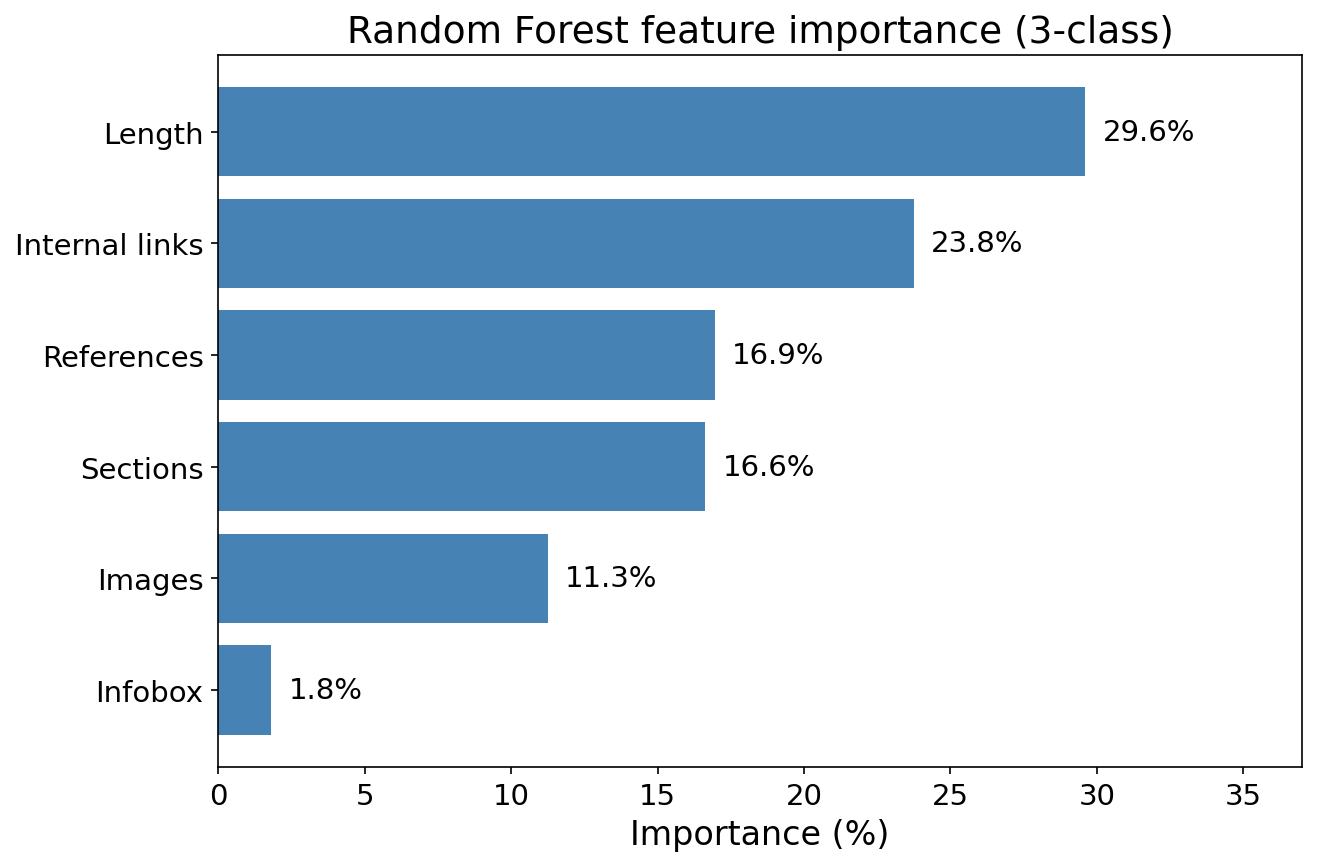

In [14]:
importances_3class = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Feature importances (Random Forest, 3-class):")
print(importances_3class)
print(f"\n-> Article length: {importances_3class['length']*100:.1f}%")
print(f"-> Internal links: {importances_3class['links']*100:.1f}%")
print(f"-> References: {importances_3class['refs']*100:.1f}%")

DISPLAY_NAMES = {'length':'Length','refs':'References','images':'Images','sections':'Sections','links':'Internal links','infobox':'Infobox'}
plot_order = importances_3class.sort_values()
labels = [DISPLAY_NAMES[f] for f in plot_order.index]
values_pct = plot_order.values * 100
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(labels, values_pct, color='steelblue')
ax.set_xlabel('Importance (%)')
ax.set_title('Random Forest feature importance (3-class)')
ax.set_xlim(0, values_pct.max() * 1.25)
for i, v in enumerate(values_pct):
    ax.text(v + values_pct.max() * 0.02, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', bbox_inches='tight', pad_inches=0.2)
plt.show()


In [15]:
importances_6class = pd.Series(rf_balanced.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Feature importances (Random Forest, 6-class):")
print(importances_6class)

Feature importances (Random Forest, 6-class):
length      0.281353
links       0.215046
refs        0.188827
sections    0.174025
images      0.119453
infobox     0.021296
dtype: float64


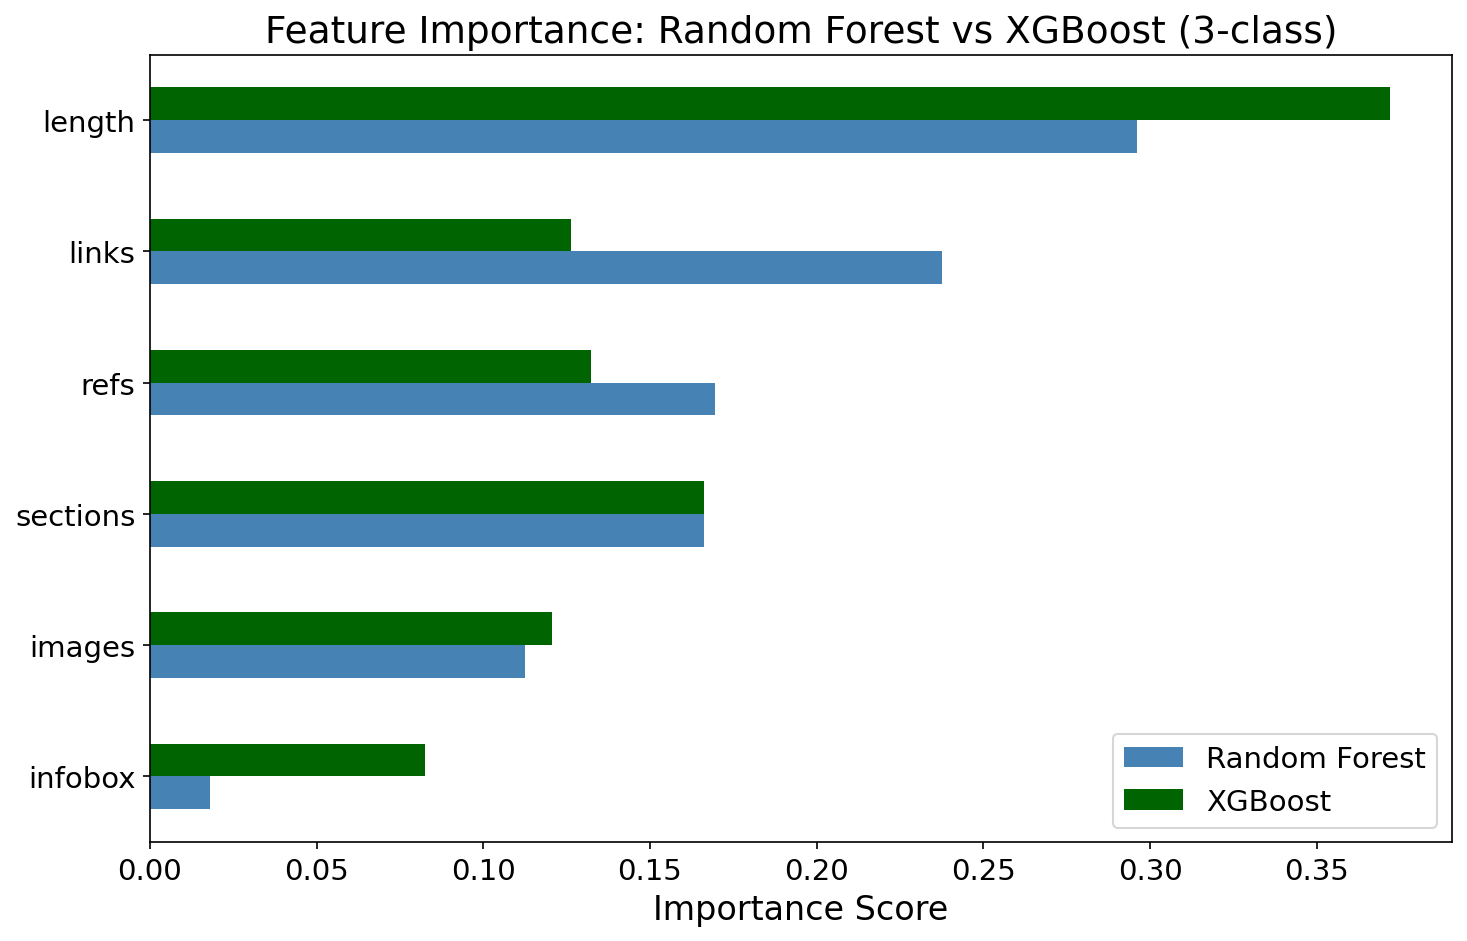

In [16]:
xgb_importances = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6.5))
comp = pd.DataFrame({'Random Forest': importances_3class, 'XGBoost': xgb_importances}).sort_values('Random Forest')
comp.plot(kind='barh', ax=ax, color=['steelblue', 'darkgreen'])
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance: Random Forest vs XGBoost (3-class)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png')
plt.show()


### 5.3 Cross Category Analysis (Table 5.7)
A separate Random Forest is trained per topic category with at least 30 articles and at least 2 quality classes represented.

In [17]:
category_results = []

for category in df['topic'].unique():
    cat_df = df[df['topic'] == category]
    if len(cat_df) < 30:
        continue
    if cat_df['quality_3class'].nunique() < 2:
        continue

    X_cat = cat_df[FEATURES]
    y_cat = cat_df['quality_3class']

    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X_cat, y_cat, test_size=0.2, random_state=RANDOM_STATE
    )

    if y_train_c.nunique() < 2:
        continue

    rf_cat = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE)
    rf_cat.fit(X_train_c, y_train_c)
    acc_cat = accuracy_score(y_test_c, rf_cat.predict(X_test_c))

    imp_cat = pd.Series(rf_cat.feature_importances_, index=FEATURES).sort_values(ascending=False)
    top_feature = imp_cat.index[0]

    category_results.append({
        'Category': category,
        'Top Feature': top_feature,
        'Accuracy': acc_cat,
        'Articles': len(cat_df)
    })

results_df = pd.DataFrame(category_results).sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))

            Category Top Feature  Accuracy  Articles
Science & Technology       links  0.882353       252
  History & Politics      length  0.811321       263
             General      length  0.756410       387
           Biography      length  0.714286        35
           Geography      length  0.694444       179
      Culture & Arts      length  0.666667        71


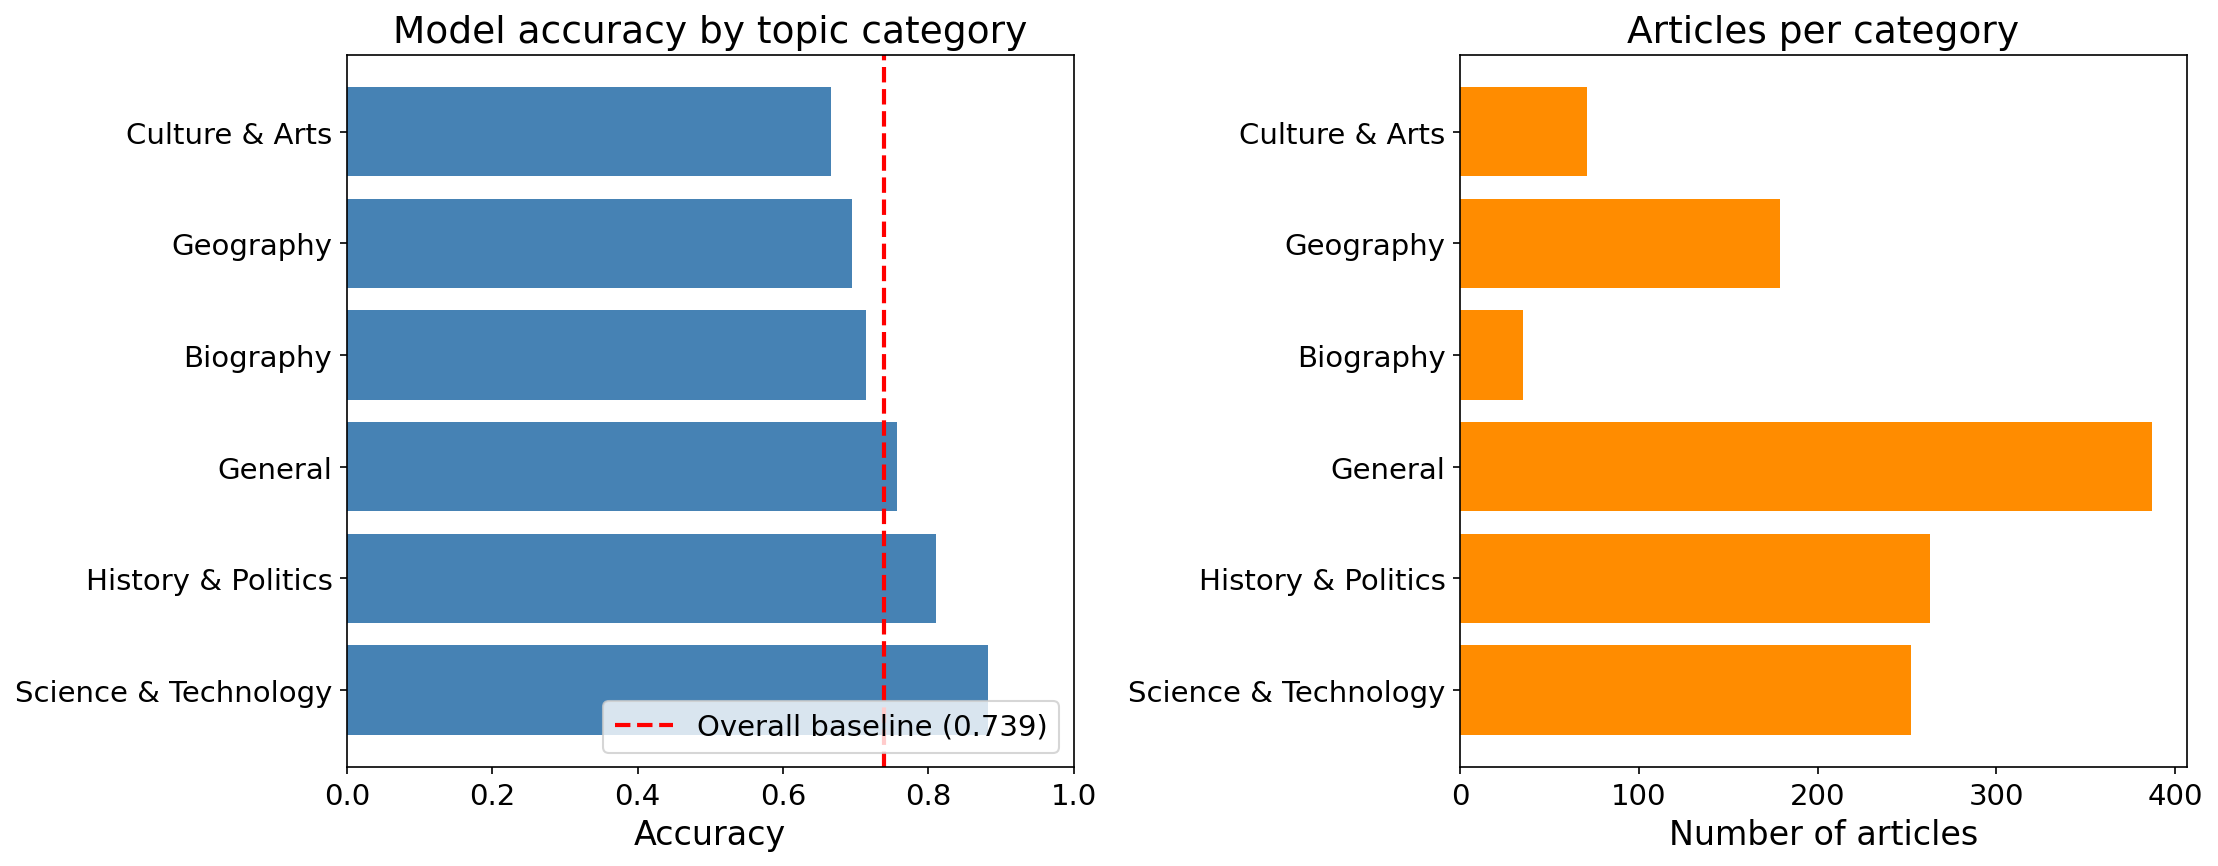

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(results_df['Category'], results_df['Accuracy'], color='steelblue')
axes[0].axvline(rf_test_acc, color='red', linestyle='--', linewidth=2, label=f'Overall baseline ({rf_test_acc:.3f})')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model accuracy by topic category')
axes[0].legend(loc='lower right')
axes[0].set_xlim(0, 1.0)

axes[1].barh(results_df['Category'], results_df['Articles'], color='darkorange')
axes[1].set_xlabel('Number of articles')
axes[1].set_title('Articles per category')

plt.tight_layout()
plt.savefig('cross_category_results.png')
plt.show()


In [19]:
tiers = ['Stub','Start','C','B','GA','FA']
print("F1 without balanced weighting:", dict(zip(tiers, np.round(f1_unbalanced, 3))))
print("F1 with balanced weighting:   ", dict(zip(tiers, np.round(f1_balanced, 3))))

F1 without balanced weighting: {'Stub': np.float64(0.872), 'Start': np.float64(0.667), 'C': np.float64(0.427), 'B': np.float64(0.366), 'GA': np.float64(0.333), 'FA': np.float64(0.0)}
F1 with balanced weighting:    {'Stub': np.float64(0.872), 'Start': np.float64(0.682), 'C': np.float64(0.443), 'B': np.float64(0.411), 'GA': np.float64(0.182), 'FA': np.float64(0.0)}


## Summary Table

In [20]:
summary = pd.DataFrame({
    'Algorithm': ['Random Forest', 'XGBoost', 'Logistic Regression'],
    'Test Accuracy': [rf_test_acc, xgb_test_acc, lr_test_acc],
    'CV Mean': [rf_cv_scores.mean(), xgb_cv_scores.mean(), lr_cv_scores.mean()]
})
print(summary)

             Algorithm  Test Accuracy   CV Mean
0        Random Forest       0.739496  0.753941
1              XGBoost       0.735294  0.736340
2  Logistic Regression       0.600840  0.625905
